# Uber Raw Data - Displot Analysis

Load `uber-raw-data-sep14.csv`, process datetime features with pandas/numpy, and visualize trip density by day, hour, and weekday using seaborn `displot`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# sns.set_theme(style="whitegrid", palette="deep")

## 1. Load CSV data

In [2]:
data_path = Path("data/uber-raw-data-sep14.csv")
uber_df = pd.read_csv(data_path)

uber_df.head()

,Date/Time,Lat,Lon,Base
0,9/1/2014 0:01:00,40.2201,-74.0021,B02512
1,9/1/2014 0:01:00,40.7500,-74.0027,B02512
2,9/1/2014 0:03:00,40.7559,-73.9864,B02512
3,9/1/2014 0:06:00,40.7450,-73.9889,B02512
4,9/1/2014 0:11:00,40.8145,-73.9444,B02512


In [3]:
uber_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1028136 entries, 0 to 1028135
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   Date/Time  1028136 non-null  str    
 1   Lat        1028136 non-null  float64
 2   Lon        1028136 non-null  float64
 3   Base       1028136 non-null  str    
dtypes: float64(2), str(2)
memory usage: 54.4 MB


## 2. Process datetime columns

Extract day, hour, and weekday from `Date/Time` so they can be used as distribution variables.

In [4]:
uber_df["Date/Time"] = pd.to_datetime(uber_df["Date/Time"], format="%m/%d/%Y %H:%M:%S")

uber_df["day"] = uber_df["Date/Time"].dt.day
uber_df["hour"] = uber_df["Date/Time"].dt.hour
uber_df["weekday_number"] = uber_df["Date/Time"].dt.weekday
uber_df["weekday"] = uber_df["Date/Time"].dt.day_name()

weekday_labels = np.array(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])

uber_df[["Date/Time", "day", "hour", "weekday_number", "weekday"]].head()

,Date/Time,day,hour,weekday_number,weekday
0,2014-09-01 00:01:00,1,0,0,Monday
1,2014-09-01 00:01:00,1,0,0,Monday
2,2014-09-01 00:03:00,1,0,0,Monday
3,2014-09-01 00:06:00,1,0,0,Monday
4,2014-09-01 00:11:00,1,0,0,Monday


In [31]:
uber_df[["day", "hour", "weekday_number"]].describe()

,day,hour,weekday_number
count,1.028136e+06,1.028136e+06,1.028136e+06
mean,1.555385e+01,1.409235e+01,2.961477e+00
std,8.448335e+00,5.971244e+00,1.942572e+00
min,1.000000e+00,0.000000e+00,0.000000e+00
25%,8.000000e+00,1.000000e+01,1.000000e+00
50%,1.600000e+01,1.500000e+01,3.000000e+00
75%,2.300000e+01,1.900000e+01,5.000000e+00
max,3.000000e+01,2.300000e+01,6.000000e+00


## 3. Density vs. Day

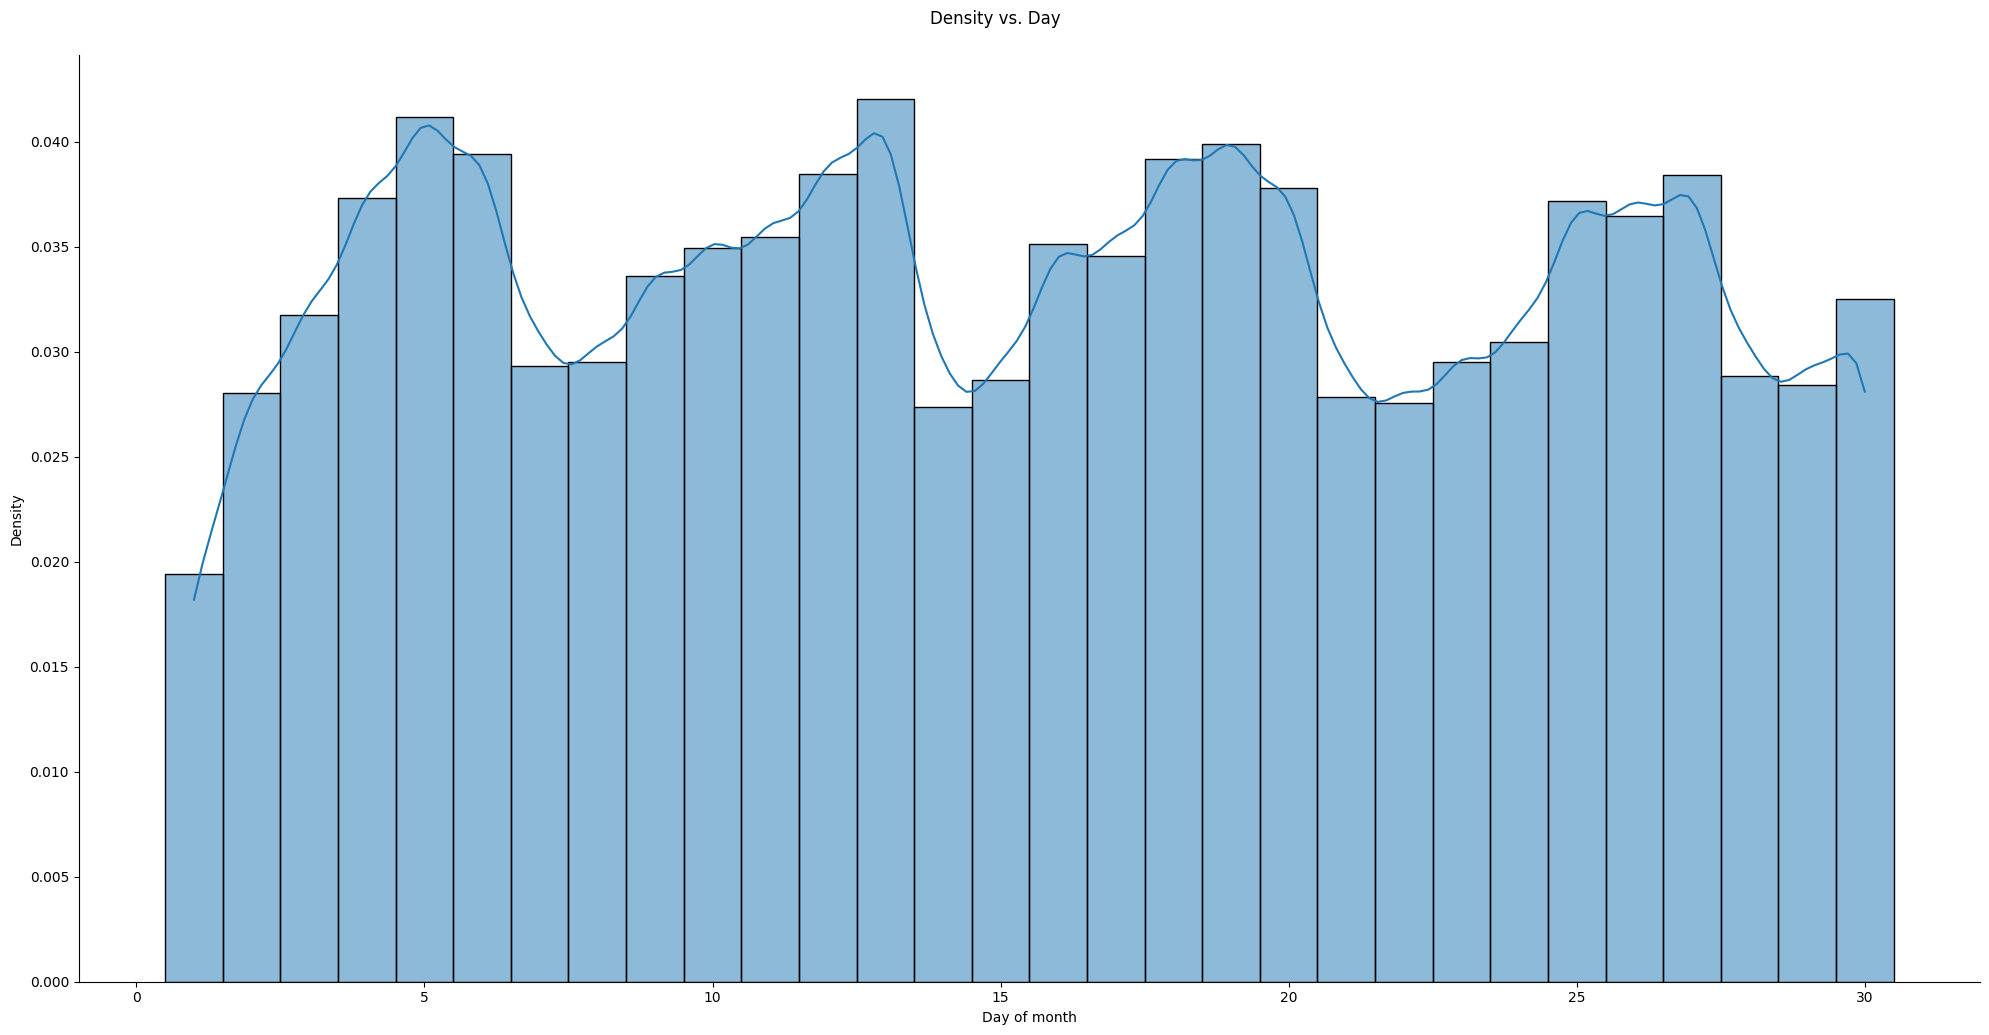

In [30]:
day_plot = sns.displot(
    data=uber_df,
    x="day",
    stat="density",
    kde=True,
    discrete=True,
    height=10,
    aspect=2,
)
day_plot.set_axis_labels("Day of month", "Density")
day_plot.set_titles("Uber trip density by day")
day_plot.fig.suptitle("Density vs. Day", y=1.03)
plt.show()

## 4. Density vs. Hour

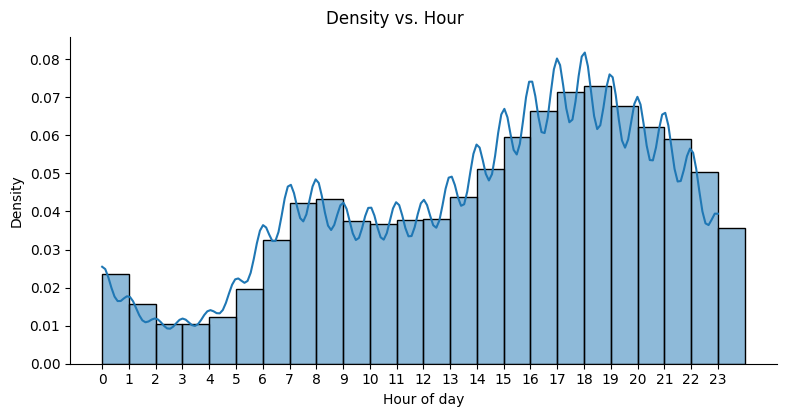

In [36]:
hour_plot = sns.displot(
    data=uber_df,
    x="hour",
    stat="density",
    kde=True,
    bins=24,
    binrange=(0, 24),
    height=4,
    aspect=2,
)
hour_plot.set_axis_labels("Hour of day", "Density")
hour_plot.set_titles("Uber trip density by hour")
hour_plot.fig.suptitle("Density vs. Hour", y=1.03)
plt.xticks(range(0, 24))
plt.show()

## 5. Density vs. Weekday

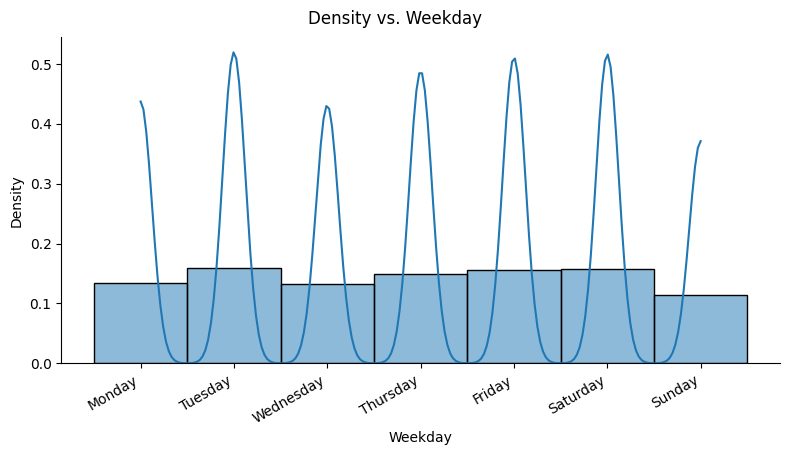

In [ ]:
weekday_plot = sns.displot(
    data=uber_df,
    x="weekday_number",
    stat="density",
    kde=True,
    discrete=True,
    height=4,
    aspect=2,
)
weekday_plot.set_axis_labels("Weekday", "Density")
weekday_plot.set_titles("Uber trip density by weekday")
weekday_plot.fig.suptitle("Density vs. Weekday", y=1.03)
plt.xticks(range(7), weekday_labels, rotation=30, ha="right")
plt.show()

## 6. Heatmap: Weekday vs. Hour

hour              0     1     2     3     4     5     6     7     8     9   \
weekday_number                                                               
0               1885  1201   977  1780  2479  3905  5668  7223  7287  5892   
1               1411   784   609  1221  2093  4196  7393  9466  9374  7082   
2               1489   885   597   966  1612  3130  5699  7067  6665  5356   
3               1762  1037   714  1088  1720  2754  5586  7790  7663  6330   
4               2513  1530  1002  1347  1819  3115  5186  6698  6715  5615   
5               6909  4737  2957  2029  1458  1544  2092  2790  3664  4352   
6               8164  5933  3846  2358  1494  1618  1683  2280  3109  3915   

hour            ...    14    15     16     17     18     19     20     21  \
weekday_number  ...                                                         
0               ...  7113  8346   9513   9841   9611   8725   8318   6979   
1               ...  8374  9935  11108  12369  12184  11091  10370

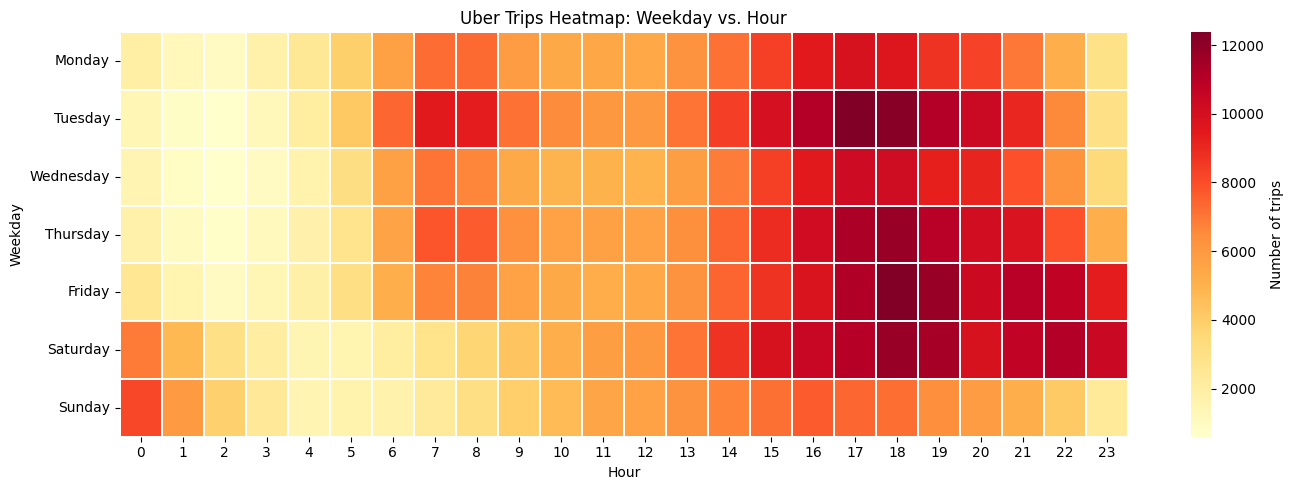

In [28]:
weekday_hour_counts = (
    uber_df.groupby(["weekday_number", "hour"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=range(7), columns=range(24), fill_value=0)
)

x = uber_df.groupby(["weekday_number", "hour"]).size().unstack(fill_value=0)
print(x)

plt.figure(figsize=(14, 5))
sns.heatmap(
    weekday_hour_counts,
    cmap="YlOrRd",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Number of trips"},
)
plt.title("Uber Trips Heatmap: Weekday vs. Hour")
plt.xlabel("Hour")
plt.ylabel("Weekday")
plt.yticks(np.arange(7) + 0.5, weekday_labels, rotation=0)
plt.xticks(np.arange(24) + 0.5, range(24), rotation=0)
plt.tight_layout()
plt.show()

## 7. Scatter: Lat vs. Lon

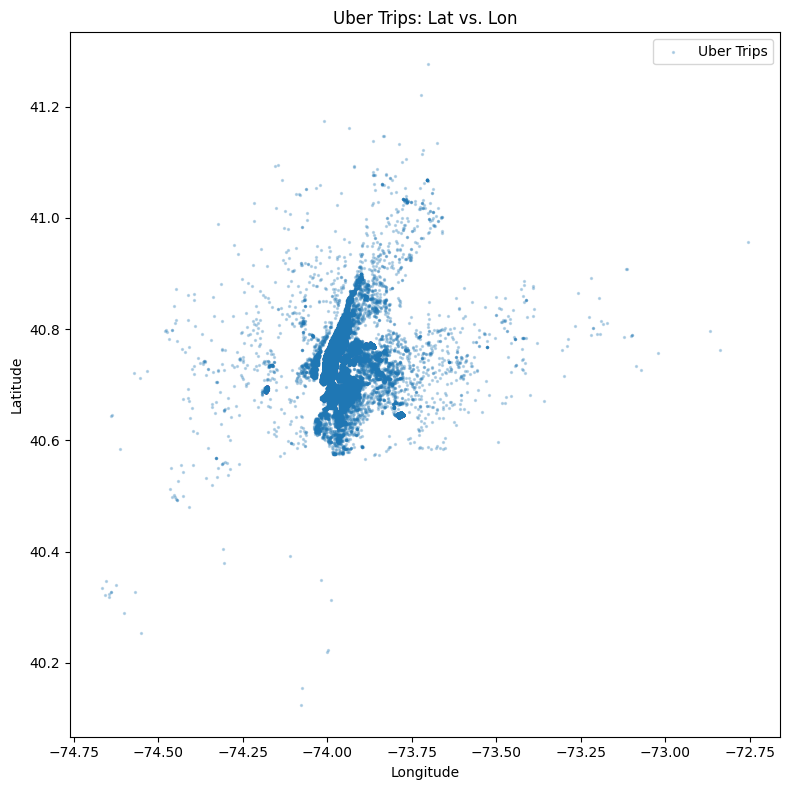

In [10]:
scatter_df = uber_df.sample(n=min(100_000, len(uber_df)), random_state=42)

plt.figure(figsize=(8, 8))
plt.scatter(
    scatter_df["Lon"],
    scatter_df["Lat"],
    s=2,
    alpha=0.25,
    label="Uber Trips",
)
plt.title("Uber Trips: Lat vs. Lon")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.tight_layout()
plt.show()